# Dynamic parametrisation accuracy

Simple working notebook for checking one selected Bernese parametrisation from `.OUT` files.

Main modes:

- `ZA` - basic parametrisation, evaluated from ORBGEN fit RMS.
- `ZG` - dynamic parametrisation, evaluated from ORBGEN fit RMS.

Optional mode:

- `ZAZG` - STDDIF comparison between `ZA` and `ZG`.

In [1]:
# ============================================================
# 1) IMPORTS
# ============================================================

import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# doris src
_src = Path("../..").resolve() / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from doris.input.ssh import download_from_ssh
from doris.input.local import copy_from_local
from doris.analysis.spectral import compute_periodogram

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.6f}".format)

print("CWD:", Path.cwd())
print("OK")

CWD: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\notebooks\tests
OK


In [2]:
# ============================================================
# 2) PARAMETERS
# ============================================================

# SUM file. It may contain remote OUT paths.
SUM_PATH = Path(r"C:\Users\michal\Desktop\bernese\vysledky\cmorb_SA_ZA_ZG_24_001_030.SUM")

# Select one mode: ZA, ZG, or ZAZG.
SOLUTION = "ZG"

# Satellite and days.
SAT = "SA"       # SA, S6, J3, or None for all
DOY_FROM = 1
DOY_TO = 30

# ORBGEN iteration for ZA/ZG files.
ITERATION = 2

# Project root (dva adresáře nad notebooks/tests/).
_PROJECT_ROOT = Path("../..").resolve()

# Hlavní složka pro stažené OUT soubory.
DOWNLOAD_DIR = _PROJECT_ROOT / "data" / "bernese"

# Work folders for derived tables.
WORKDIR = Path("work_dynamic_parametrisation_accuracy")
EXPORT_DIR = WORKDIR / "exports"

# Složka pro ukládání grafů.
PLOTS_DIR = _PROJECT_ROOT / "LaTeX" / "images" / "test" / "dynamic_precision"

# Download is disabled by default.
USE_SSH_DOWNLOAD = True
SSH_HOST = "amalie.pecny.cz"
SSH_PORT = 22
SSH_USERNAME = "mkovar"
SSH_LOGIN_FILE = Path("login_ssh.txt")

# Plots and exports.
SAVE_PLOTS = False
FIGSIZE = (12, 5)

# Normalize settings.
SOLUTION = SOLUTION.upper()
if SAT is not None:
    SAT = SAT.upper()

# Create folders.
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
WORKDIR.mkdir(exist_ok=True)
EXPORT_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("SUM_PATH   :", SUM_PATH, "| exists=", SUM_PATH.exists())
print("SOLUTION   :", SOLUTION)
print("SAT        :", SAT)
print("DOY        :", DOY_FROM, "-", DOY_TO)
print("DOWNLOAD_DIR:", DOWNLOAD_DIR)
print("PLOTS_DIR  :", PLOTS_DIR)
print("WORKDIR    :", WORKDIR.resolve())

SUM_PATH   : C:\Users\michal\Desktop\bernese\vysledky\cmorb_SA_ZA_ZG_24_001_030.SUM | exists= True
SOLUTION   : ZG
SAT        : SA
DOY        : 1 - 30
DOWNLOAD_DIR: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\bernese
PLOTS_DIR  : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\test\dynamic_precision
WORKDIR    : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\notebooks\tests\work_dynamic_parametrisation_accuracy


In [3]:
# ============================================================
# 3) SSH DOWNLOAD
# ============================================================

# Vzdálená složka se načte ze SUM souboru.
_remote_re = re.compile(r"(?P<remote>/\S+/)[A-Za-z0-9]+\d{3}0(?:ZAZG|ZA|ZG)\.OUT", re.I)
_remote_dir = None
if SUM_PATH.exists():
    _m = _remote_re.search(SUM_PATH.read_text(encoding="utf-8", errors="ignore"))
    if _m:
        _remote_dir = _m.group("remote").rstrip("/")

print("Remote dir ze SUM:", _remote_dir)

_sat_pattern = SAT.lower() if SAT else "*"
_out_glob = f"{_sat_pattern}*0{SOLUTION}.OUT"

if not USE_SSH_DOWNLOAD:
    print("USE_SSH_DOWNLOAD=False -> stahování je vypnuto.")
elif not _remote_dir:
    print("Vzdálená složka nenalezena v SUM souboru.")
else:
    result = download_from_ssh(
        host=SSH_HOST,
        port=SSH_PORT,
        username=SSH_USERNAME,
        remote_dir=_remote_dir,
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        login_file=SSH_LOGIN_FILE,
        overwrite=False,
        decompress=False,
        keep_compressed=True,
    )
    print(f"Staženo: {result.count_downloaded}, přeskočeno: {result.count_skipped_existing}")

Remote dir ze SUM: /home/doris/GPSDATA/DORIS_B/OUT


Downloading:   0%|          | 0/30 [00:00<?, ?file/s]

Staženo: 30, přeskočeno: 0


In [4]:
# ============================================================
# 4) CONSOLIDATE LOCAL OUT FILES INTO DOWNLOAD_DIR
# ============================================================

# Vzor přesně odpovídá formátu SA0010ZG.OUT (vylučuje ZAZG).
_sat_pattern = SAT.lower() if SAT else "*"
_out_glob = f"{_sat_pattern}*0{SOLUTION}.OUT"

# a) Kopie ze složky vedle SUM souboru (pokud je jiná než DOWNLOAD_DIR).
if SUM_PATH.parent.exists() and SUM_PATH.parent.resolve() != DOWNLOAD_DIR.resolve():
    r = copy_from_local(
        source_dir=SUM_PATH.parent,
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        overwrite=False,
    )
    print(f"SUM složka: zkopírováno {r.count_copied}, přeskočeno {r.count_skipped_existing}")

# b) Záložní lokální složka (nastav cestu pokud máš soubory jinde).
_FALLBACK_DIR = None   # např. Path(r"C:\stara\slozka\downloaded_out")
if _FALLBACK_DIR and Path(_FALLBACK_DIR).exists():
    r = copy_from_local(
        source_dir=Path(_FALLBACK_DIR),
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        overwrite=False,
    )
    print(f"Záložní složka: zkopírováno {r.count_copied}, přeskočeno {r.count_skipped_existing}")

# ============================================================
# 5) FIND LOCAL OUT FILES
# ============================================================

out_name_re = re.compile(r"^(?P<sat>[A-Za-z0-9]+?)(?P<doy>\d{3})0(?P<solution>ZAZG|ZA|ZG)\.OUT$", re.I)

_FILE_COLS = ["sat", "doy", "solution", "file", "path", "size_kb"]
rows = []

for path in DOWNLOAD_DIR.glob("*.OUT"):
    m = out_name_re.match(path.name)
    if not m:
        continue

    sat = m.group("sat").upper()
    doy = int(m.group("doy"))
    solution = m.group("solution").upper()

    if solution != SOLUTION:
        continue
    if SAT is not None and sat != SAT:
        continue
    if not (DOY_FROM <= doy <= DOY_TO):
        continue

    rows.append({
        "sat": sat,
        "doy": doy,
        "solution": solution,
        "file": path.name,
        "path": path,
        "size_kb": path.stat().st_size / 1024,
    })

files_df = (
    pd.DataFrame(rows, columns=_FILE_COLS)
    .sort_values(["sat", "doy", "file"])
    .reset_index(drop=True)
)

print(f"Nalezeno souborů: {len(files_df)}")
if not files_df.empty:
    display(files_df)

Copying: 0file [00:00, ?file/s]

Decompressing: 0file [00:00, ?file/s]

SUM složka: zkopírováno 0, přeskočeno 0
Nalezeno souborů: 30


,sat,doy,solution,file,path,size_kb
0,SA,1,ZG,SA0010ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
1,SA,2,ZG,SA0020ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
2,SA,3,ZG,SA0030ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
3,SA,4,ZG,SA0040ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
4,SA,5,ZG,SA0050ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,341.936523
5,SA,6,ZG,SA0060ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
6,SA,7,ZG,SA0070ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.067383
7,SA,8,ZG,SA0080ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
8,SA,9,ZG,SA0090ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
9,SA,10,ZG,SA0100ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953


In [5]:
# ============================================================
# 6) CHECK DAY COVERAGE
# ============================================================

if SAT is None:
    print("SAT=None, přeskočena kontrola pokrytí.")
else:
    expected = pd.DataFrame({
        "sat": SAT,
        "doy": range(DOY_FROM, DOY_TO + 1),
        "solution": SOLUTION,
    })

    coverage_df = expected.merge(
        files_df[["sat", "doy", "solution", "file", "path"]],
        on=["sat", "doy", "solution"],
        how="left",
    )
    coverage_df["found"] = coverage_df["file"].notna()

    print("Očekáváno:", len(coverage_df))
    print("Nalezeno :", int(coverage_df["found"].sum()))
    print("Chybí   :", int((~coverage_df["found"]).sum()))

    display(coverage_df)

Očekáváno: 30
Nalezeno : 30
Chybí   : 0


,sat,doy,solution,file,path,found
0,SA,1,ZG,SA0010ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
1,SA,2,ZG,SA0020ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
2,SA,3,ZG,SA0030ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
3,SA,4,ZG,SA0040ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
4,SA,5,ZG,SA0050ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
5,SA,6,ZG,SA0060ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
6,SA,7,ZG,SA0070ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
7,SA,8,ZG,SA0080ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
8,SA,9,ZG,SA0090ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
9,SA,10,ZG,SA0100ZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True


## ORBGEN fit RMS

For `ZA` and `ZG`, the main accuracy indicator in these `.OUT` files is the block `RMS ERRORS AND MAX. RESIDUALS`.

The values are in meters in the file. The notebook converts them to millimeters.


In [6]:
# ============================================================
# 7) PARSE ORBGEN FIT RMS FROM ZA/ZG OUT FILES
# ============================================================

rms_block_re = re.compile(
    r"RMS ERRORS AND MAX\. RESIDUALS\s+ARC NUMBER:\s*(\d+)\s+ITERATION:\s*(\d+)"
    r"(.*?)(?=\n\s*-{5,}\s*\n\s*\n\s*-{5,}\s*\n\s*RPR PARAMETERS|\n\s*RPR PARAMETERS|\Z)",
    re.S,
)

rms_row_re = re.compile(
    r"^\s*(\d+)\s+(\d+)\s+"
    r"([+\-]?\d+\.\d+)\s+"
    r"([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+"
    r"([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s*$",
    re.M,
)


def parse_orbgen_fit_out(path, sat, doy, solution, iteration):
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    rows = []

    for block in rms_block_re.finditer(text):
        arc_number = int(block.group(1))
        block_iteration = int(block.group(2))
        if block_iteration != iteration:
            continue

        row = rms_row_re.search(block.group(3))
        if row is None:
            continue

        rows.append({
            "sat": sat,
            "doy": doy,
            "solution": solution,
            "arc_number": arc_number,
            "iteration": block_iteration,
            "bernese_sat_id": int(row.group(1)),
            "n_pos": int(row.group(2)),
            "fit_rms_mm": float(row.group(3)) * 1000.0,
            "total_rms_mm": float(row.group(4)) * 1000.0,
            "radial_rms_mm": float(row.group(5)) * 1000.0,
            "along_rms_mm": float(row.group(6)) * 1000.0,
            "out_rms_mm": float(row.group(7)) * 1000.0,
            "radial_max_mm": float(row.group(8)) * 1000.0,
            "along_max_mm": float(row.group(9)) * 1000.0,
            "out_max_mm": float(row.group(10)) * 1000.0,
            "source_file": Path(path).name,
        })

    return rows


if SOLUTION == "ZAZG":
    fit_arc_df = pd.DataFrame()
    print("SOLUTION=ZAZG -> ORBGEN fit parser přeskočen.")
else:
    all_rows = []
    for _, file_row in files_df.iterrows():
        all_rows.extend(
            parse_orbgen_fit_out(
                file_row["path"],
                sat=file_row["sat"],
                doy=int(file_row["doy"]),
                solution=file_row["solution"],
                iteration=ITERATION,
            )
        )

    fit_arc_df = pd.DataFrame(all_rows)
    if not fit_arc_df.empty:
        fit_arc_df = fit_arc_df.sort_values(["sat", "doy", "arc_number"]).reset_index(drop=True)

    print("Parsed arc rows:", len(fit_arc_df))
    if not fit_arc_df.empty:
        display(fit_arc_df.head(20))

Parsed arc rows: 480


,sat,doy,solution,arc_number,iteration,bernese_sat_id,n_pos,fit_rms_mm,total_rms_mm,radial_rms_mm,along_rms_mm,out_rms_mm,radial_max_mm,along_max_mm,out_max_mm,source_file
0,SA,1,ZG,1,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT
1,SA,1,ZG,2,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT
2,SA,1,ZG,3,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT
3,SA,1,ZG,4,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT
4,SA,1,ZG,5,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,5.000000,1.000000,SA0010ZG.OUT
5,SA,1,ZG,6,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT
6,SA,1,ZG,7,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT
7,SA,1,ZG,8,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT
8,SA,1,ZG,9,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT
9,SA,1,ZG,10,2,926,91,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,SA0010ZG.OUT


In [7]:
# ============================================================
# 8) DAILY AND GLOBAL SUMMARY
# ============================================================

if fit_arc_df.empty:
    print("fit_arc_df is empty -> nothing to summarize.")
else:
    fit_daily_df = (
        fit_arc_df
        .groupby(["sat", "doy", "solution"], as_index=False)
        .agg(
            arc_count=("arc_number", "count"),
            n_pos_total=("n_pos", "sum"),
            fit_rms_mm_mean=("fit_rms_mm", "mean"),
            total_rms_mm_mean=("total_rms_mm", "mean"),
            radial_rms_mm_mean=("radial_rms_mm", "mean"),
            along_rms_mm_mean=("along_rms_mm", "mean"),
            out_rms_mm_mean=("out_rms_mm", "mean"),
            radial_max_mm_max=("radial_max_mm", "max"),
            along_max_mm_max=("along_max_mm", "max"),
            out_max_mm_max=("out_max_mm", "max"),
        )
        .sort_values(["sat", "doy"])
        .reset_index(drop=True)
    )

    fit_daily_df["rtn_3d_rms_mm"] = np.sqrt(
        fit_daily_df["radial_rms_mm_mean"]**2 +
        fit_daily_df["along_rms_mm_mean"]**2 +
        fit_daily_df["out_rms_mm_mean"]**2
    )

    global_summary = pd.DataFrame([{
        "sat": SAT,
        "solution": SOLUTION,
        "n_days": fit_daily_df["doy"].nunique(),
        "n_arcs": len(fit_arc_df),
        "fit_rms_mm_mean": fit_arc_df["fit_rms_mm"].mean(),
        "total_rms_mm_mean": fit_arc_df["total_rms_mm"].mean(),
        "radial_rms_mm_mean": fit_arc_df["radial_rms_mm"].mean(),
        "along_rms_mm_mean": fit_arc_df["along_rms_mm"].mean(),
        "out_rms_mm_mean": fit_arc_df["out_rms_mm"].mean(),
        "radial_max_mm_max": fit_arc_df["radial_max_mm"].max(),
        "along_max_mm_max": fit_arc_df["along_max_mm"].max(),
        "out_max_mm_max": fit_arc_df["out_max_mm"].max(),
    }])

    display(global_summary)
    display(fit_daily_df.head(30))


,sat,solution,n_days,n_arcs,fit_rms_mm_mean,total_rms_mm_mean,radial_rms_mm_mean,along_rms_mm_mean,out_rms_mm_mean,radial_max_mm_max,along_max_mm_max,out_max_mm_max
0,SA,ZG,30,480,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,5.000000,1.000000


,sat,doy,solution,arc_count,n_pos_total,fit_rms_mm_mean,total_rms_mm_mean,radial_rms_mm_mean,along_rms_mm_mean,out_rms_mm_mean,radial_max_mm_max,along_max_mm_max,out_max_mm_max,rtn_3d_rms_mm
0,SA,1,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,5.000000,1.000000,2.000000
1,SA,2,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,2.000000
2,SA,3,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,2.000000
3,SA,4,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,5.000000,1.000000,2.000000
4,SA,5,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,5.000000,1.000000,2.000000
5,SA,6,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,5.000000,1.000000,2.000000
6,SA,7,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,5.000000,1.000000,2.000000
7,SA,8,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,2.000000
8,SA,9,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,5.000000,1.000000,2.000000
9,SA,10,ZG,16,1440,1.000000,1.000000,0.000000,2.000000,0.000000,1.000000,4.000000,1.000000,2.000000


In [8]:
# ============================================================
# 9) EXPORT TABLES
# ============================================================

if fit_arc_df.empty:
    print("Nothing to export.")
else:
    arc_csv = EXPORT_DIR / f"{SOLUTION.lower()}_orbgen_fit_arcs_iter{ITERATION}.csv"
    daily_csv = EXPORT_DIR / f"{SOLUTION.lower()}_orbgen_fit_daily_iter{ITERATION}.csv"
    summary_csv = EXPORT_DIR / f"{SOLUTION.lower()}_orbgen_fit_summary_iter{ITERATION}.csv"

    fit_arc_df.to_csv(arc_csv, index=False)
    fit_daily_df.to_csv(daily_csv, index=False)
    global_summary.to_csv(summary_csv, index=False)

    print("Saved:")
    print(" ", arc_csv)
    print(" ", daily_csv)
    print(" ", summary_csv)


Saved:
  work_dynamic_parametrisation_accuracy\exports\zg_orbgen_fit_arcs_iter2.csv
  work_dynamic_parametrisation_accuracy\exports\zg_orbgen_fit_daily_iter2.csv
  work_dynamic_parametrisation_accuracy\exports\zg_orbgen_fit_summary_iter2.csv


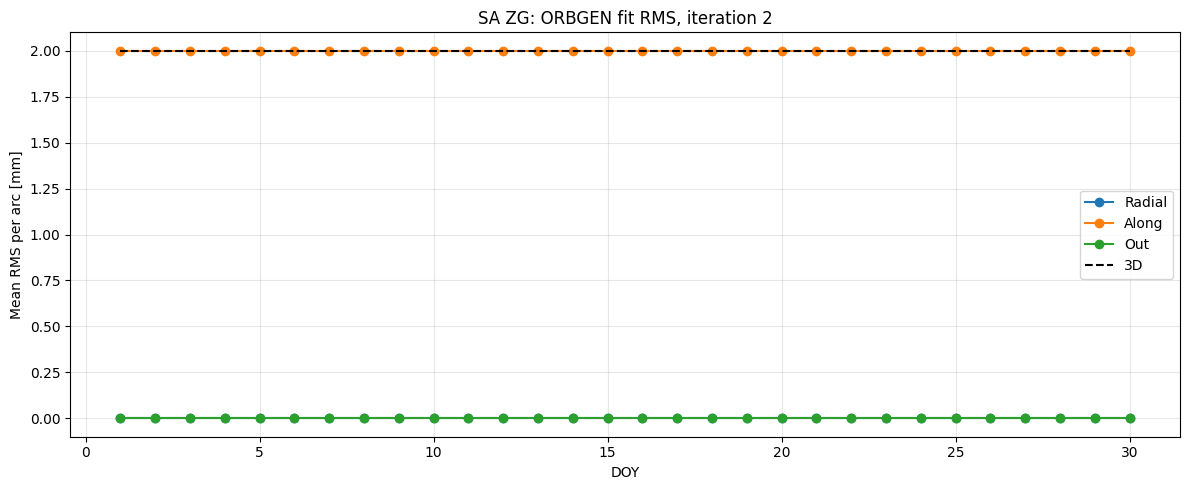

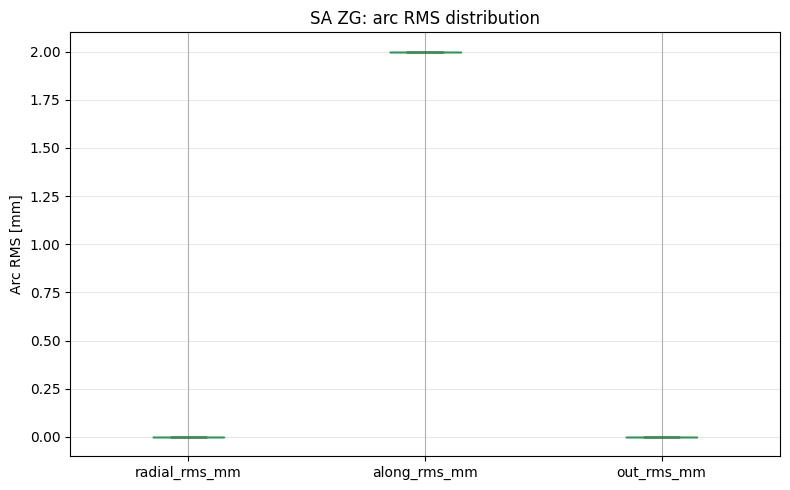

In [9]:
# ============================================================
# 10) PLOTS FOR ZA/ZG FIT ACCURACY
# ============================================================

if fit_arc_df.empty:
    print("Nothing to plot.")
else:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(fit_daily_df["doy"], fit_daily_df["radial_rms_mm_mean"], "o-", label="Radial")
    ax.plot(fit_daily_df["doy"], fit_daily_df["along_rms_mm_mean"], "o-", label="Along")
    ax.plot(fit_daily_df["doy"], fit_daily_df["out_rms_mm_mean"], "o-", label="Out")
    ax.plot(fit_daily_df["doy"], fit_daily_df["rtn_3d_rms_mm"], "k--", label="3D")
    ax.set_xlabel("DOY")
    ax.set_ylabel("Mean RMS per arc [mm]")
    ax.set_title(f"{SAT or 'ALL'} {SOLUTION}: ORBGEN fit RMS, iteration {ITERATION}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOTS_DIR / f"{SOLUTION.lower()}_daily_rms_iter{ITERATION}.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    fit_arc_df[["radial_rms_mm", "along_rms_mm", "out_rms_mm"]].boxplot(ax=ax)
    ax.set_ylabel("Arc RMS [mm]")
    ax.set_title(f"{SAT or 'ALL'} {SOLUTION}: arc RMS distribution")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOTS_DIR / f"{SOLUTION.lower()}_arc_rms_boxplot_iter{ITERATION}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [10]:
# ============================================================
# 11) PARSE EPOCH RESIDUALS
# ============================================================

residual_block_re = re.compile(
    r"RESIDUALS \(M\)\s+ARC NUMBER:\s*(\d+)\s+ITERATION:\s*(\d+)"
    r"(.*?)(?=\n\s*-{5,}\s*\n\s*\n\s*-{5,}\s*\n\s*RMS ERRORS|\n\s*RMS ERRORS|\Z)",
    re.S,
)

residual_row_re = re.compile(
    r"^\s*(\d{4}-\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2})\s+"
    r"(\d+)\s+([-+]?\d+\.\d+)\s+([-+]?\d+\.\d+)\s+([-+]?\d+\.\d+)\s+"
    r"([-+]?\d+\.\d+)\s+([YN])\s*$",
    re.M,
)


def parse_residual_epochs(path, sat, doy, solution, iteration):
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    rows = []

    for block in residual_block_re.finditer(text):
        arc_number = int(block.group(1))
        block_iteration = int(block.group(2))
        if block_iteration != iteration:
            continue

        for m in residual_row_re.finditer(block.group(3)):
            rows.append({
                "sat": sat,
                "doy": doy,
                "solution": solution,
                "arc_number": arc_number,
                "iteration": block_iteration,
                "epoch": pd.to_datetime(m.group(1) + " " + m.group(2)),
                "bernese_sat_id": int(m.group(3)),
                "radial_mm": float(m.group(4)) * 1000.0,
                "along_mm": float(m.group(5)) * 1000.0,
                "out_mm": float(m.group(6)) * 1000.0,
                "int_error_mm": float(m.group(7)) * 1000.0,
                "sun": m.group(8),
                "source_file": Path(path).name,
            })

    return rows


if SOLUTION == "ZAZG":
    residuals_df = pd.DataFrame()
    print("SOLUTION=ZAZG -> residual epoch parser přeskočen.")
else:
    rows = []
    for _, file_row in files_df.iterrows():
        rows.extend(
            parse_residual_epochs(
                file_row["path"],
                sat=file_row["sat"],
                doy=int(file_row["doy"]),
                solution=file_row["solution"],
                iteration=ITERATION,
            )
        )

    residuals_df = pd.DataFrame(rows)
    if not residuals_df.empty:
        residuals_df = residuals_df.sort_values(["sat", "doy", "arc_number", "epoch"]).reset_index(drop=True)
        residuals_df["rtn_3d_mm"] = np.sqrt(
            residuals_df["radial_mm"]**2 + residuals_df["along_mm"]**2 + residuals_df["out_mm"]**2
        )

    print("Parsed residual epochs:", len(residuals_df))
    if not residuals_df.empty:
        display(residuals_df.head(20))

Parsed residual epochs: 43200


,sat,doy,solution,arc_number,iteration,epoch,bernese_sat_id,radial_mm,along_mm,out_mm,int_error_mm,sun,source_file,rtn_3d_mm
0,SA,1,ZG,1,2,2024-01-01 00:00:00,926,0.000000,-0.640000,-0.100000,0.000000,Y,SA0010ZG.OUT,0.647765
1,SA,1,ZG,1,2,2024-01-01 00:01:00,926,0.130000,-2.750000,0.120000,0.000000,Y,SA0010ZG.OUT,2.755685
2,SA,1,ZG,1,2,2024-01-01 00:02:00,926,0.090000,3.310000,-0.060000,0.000000,Y,SA0010ZG.OUT,3.311767
3,SA,1,ZG,1,2,2024-01-01 00:03:00,926,0.440000,2.030000,-0.070000,0.000000,Y,SA0010ZG.OUT,2.078317
4,SA,1,ZG,1,2,2024-01-01 00:04:00,926,0.130000,-1.620000,-0.170000,0.000000,Y,SA0010ZG.OUT,1.634075
5,SA,1,ZG,1,2,2024-01-01 00:05:00,926,-0.250000,2.780000,0.210000,0.000000,Y,SA0010ZG.OUT,2.799107
6,SA,1,ZG,1,2,2024-01-01 00:06:00,926,0.080000,1.820000,-0.330000,0.000000,Y,SA0010ZG.OUT,1.851405
7,SA,1,ZG,1,2,2024-01-01 00:07:00,926,0.430000,-2.230000,0.350000,0.000000,Y,SA0010ZG.OUT,2.297890
8,SA,1,ZG,1,2,2024-01-01 00:08:00,926,-0.680000,-1.060000,0.060000,0.000000,Y,SA0010ZG.OUT,1.260793
9,SA,1,ZG,1,2,2024-01-01 00:09:00,926,-0.430000,1.800000,-0.290000,0.000000,Y,SA0010ZG.OUT,1.873233


In [11]:
# ============================================================
# 12) RESIDUAL SUMMARY FROM EPOCHS
# ============================================================

def rms_mm(series):
    x = series.to_numpy(dtype=float)
    return float(np.sqrt(np.mean(x**2))) if len(x) else np.nan


if residuals_df.empty:
    print("residuals_df is empty -> nothing to summarize.")
else:
    residual_daily_df = (
        residuals_df
        .groupby(["sat", "doy", "solution"], as_index=False)
        .agg(
            n_epochs=("epoch", "count"),
            radial_mean_mm=("radial_mm", "mean"),
            along_mean_mm=("along_mm", "mean"),
            out_mean_mm=("out_mm", "mean"),
            radial_rms_mm=("radial_mm", rms_mm),
            along_rms_mm=("along_mm", rms_mm),
            out_rms_mm=("out_mm", rms_mm),
            radial_max_abs_mm=("radial_mm", lambda s: s.abs().max()),
            along_max_abs_mm=("along_mm", lambda s: s.abs().max()),
            out_max_abs_mm=("out_mm", lambda s: s.abs().max()),
        )
        .sort_values(["sat", "doy"])
        .reset_index(drop=True)
    )

    residual_daily_df["rtn_3d_rms_mm"] = np.sqrt(
        residual_daily_df["radial_rms_mm"]**2 +
        residual_daily_df["along_rms_mm"]**2 +
        residual_daily_df["out_rms_mm"]**2
    )

    residual_global_summary = pd.DataFrame([{
        "sat": SAT,
        "solution": SOLUTION,
        "iteration": ITERATION,
        "n_epochs": len(residuals_df),
        "radial_rms_mm": rms_mm(residuals_df["radial_mm"]),
        "along_rms_mm": rms_mm(residuals_df["along_mm"]),
        "out_rms_mm": rms_mm(residuals_df["out_mm"]),
        "rtn_3d_rms_mm": rms_mm(residuals_df["rtn_3d_mm"]),
    }])

    display(residual_global_summary)
    display(residual_daily_df.head(30))

    residuals_df.to_csv(EXPORT_DIR / f"{SOLUTION.lower()}_residual_epochs_iter{ITERATION}.csv", index=False)
    residual_daily_df.to_csv(EXPORT_DIR / f"{SOLUTION.lower()}_residual_daily_iter{ITERATION}.csv", index=False)

,sat,solution,iteration,n_epochs,radial_rms_mm,along_rms_mm,out_rms_mm,rtn_3d_rms_mm
0,SA,ZG,2,43200,0.315144,2.069026,0.283837,2.112048


,sat,doy,solution,n_epochs,radial_mean_mm,along_mean_mm,out_mean_mm,radial_rms_mm,along_rms_mm,out_rms_mm,radial_max_abs_mm,along_max_abs_mm,out_max_abs_mm,rtn_3d_rms_mm
0,SA,1,ZG,1440,-0.003368,0.000687,-0.000514,0.307308,2.068250,0.286094,0.980000,4.650000,0.810000,2.110438
1,SA,2,ZG,1440,-0.007431,-0.000132,0.000875,0.313708,2.066038,0.284320,0.900000,4.460000,0.760000,2.108972
2,SA,3,ZG,1440,-0.008056,-0.000250,0.001090,0.311328,2.068684,0.280021,0.870000,4.480000,0.730000,2.110638
3,SA,4,ZG,1440,-0.006208,0.000222,0.000833,0.303862,2.063042,0.284597,0.870000,4.610000,0.750000,2.104630
4,SA,5,ZG,1440,-0.011069,0.000035,0.000688,0.303583,2.065709,0.284049,0.920000,4.590000,0.690000,2.107131
5,SA,6,ZG,1440,-0.002944,0.000313,0.001160,0.306900,2.078472,0.283825,1.150000,4.920000,0.770000,2.120092
6,SA,7,ZG,1440,0.001340,0.000472,-0.000396,0.313706,2.062610,0.281535,1.010000,4.530000,0.740000,2.105239
7,SA,8,ZG,1440,-0.009201,-0.000604,0.000521,0.309612,2.074560,0.285261,0.900000,4.410000,0.740000,2.116845
8,SA,9,ZG,1440,-0.012507,-0.000410,-0.000431,0.320526,2.062338,0.284409,1.000000,4.680000,0.770000,2.106387
9,SA,10,ZG,1440,-0.009535,0.000931,-0.000424,0.316551,2.072951,0.286668,0.910000,4.440000,0.740000,2.116485


Selected DOY: 1


,sat,doy,solution,arc_number,iteration,epoch,bernese_sat_id,radial_mm,along_mm,out_mm,int_error_mm,sun,source_file,rtn_3d_mm,time_h
0,SA,1,ZG,1,2,2024-01-01 00:00:00,926,0.000000,-0.640000,-0.100000,0.000000,Y,SA0010ZG.OUT,0.647765,0.000000
1,SA,1,ZG,1,2,2024-01-01 00:01:00,926,0.130000,-2.750000,0.120000,0.000000,Y,SA0010ZG.OUT,2.755685,0.016667
2,SA,1,ZG,1,2,2024-01-01 00:02:00,926,0.090000,3.310000,-0.060000,0.000000,Y,SA0010ZG.OUT,3.311767,0.033333
3,SA,1,ZG,1,2,2024-01-01 00:03:00,926,0.440000,2.030000,-0.070000,0.000000,Y,SA0010ZG.OUT,2.078317,0.050000
4,SA,1,ZG,1,2,2024-01-01 00:04:00,926,0.130000,-1.620000,-0.170000,0.000000,Y,SA0010ZG.OUT,1.634075,0.066667
5,SA,1,ZG,1,2,2024-01-01 00:05:00,926,-0.250000,2.780000,0.210000,0.000000,Y,SA0010ZG.OUT,2.799107,0.083333
6,SA,1,ZG,1,2,2024-01-01 00:06:00,926,0.080000,1.820000,-0.330000,0.000000,Y,SA0010ZG.OUT,1.851405,0.100000
7,SA,1,ZG,1,2,2024-01-01 00:07:00,926,0.430000,-2.230000,0.350000,0.000000,Y,SA0010ZG.OUT,2.297890,0.116667
8,SA,1,ZG,1,2,2024-01-01 00:08:00,926,-0.680000,-1.060000,0.060000,0.000000,Y,SA0010ZG.OUT,1.260793,0.133333
9,SA,1,ZG,1,2,2024-01-01 00:09:00,926,-0.430000,1.800000,-0.290000,0.000000,Y,SA0010ZG.OUT,1.873233,0.150000


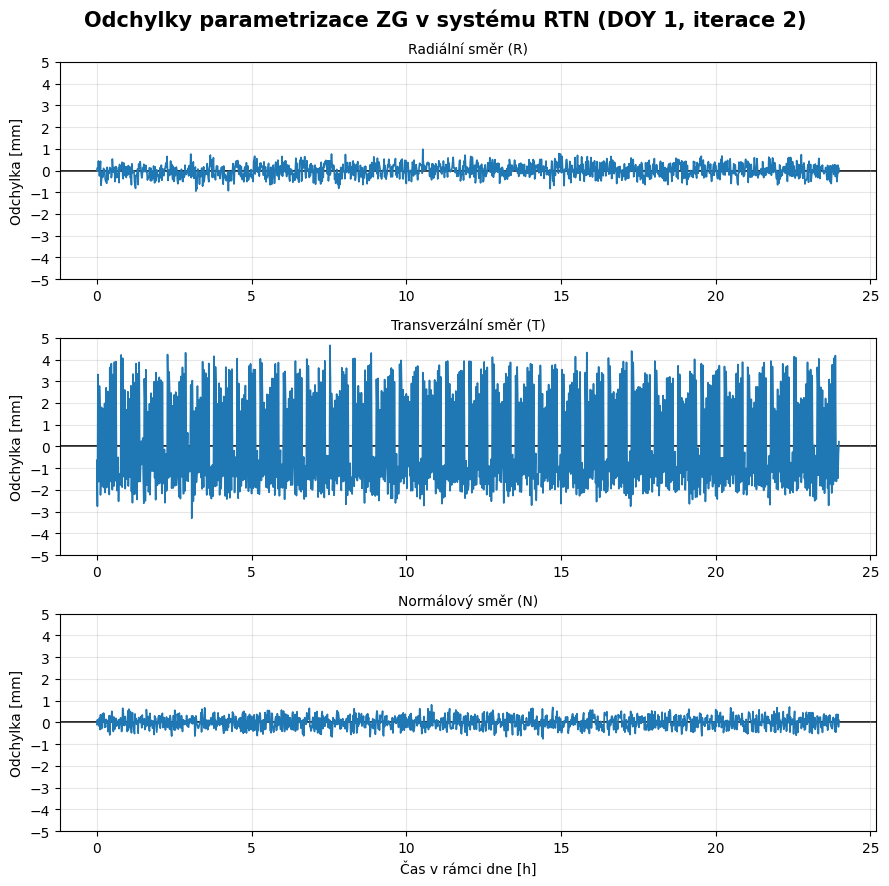

In [12]:
# ============================================================
# 13) RTN RESIDUALS FOR ONE DAY
# ============================================================

# Plot style follows the Hermite interpolation accuracy notebook.

SELECT_DOY = None   # None = first available day

if residuals_df.empty:
    print("residuals_df is empty -> nothing to plot.")
else:
    selected_doy = residuals_df["doy"].min() if SELECT_DOY is None else SELECT_DOY
    day_df = residuals_df[residuals_df["doy"] == selected_doy].copy()

    if day_df.empty:
        print("No data for SELECT_DOY:", selected_doy)
    else:
        day_start = day_df["epoch"].min()
        day_df["time_h"] = (day_df["epoch"] - day_start).dt.total_seconds() / 3600.0

        print("Selected DOY:", selected_doy)
        display(day_df.head(20))

        fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

        components = [
            ("radial_mm", "Radiální směr (R)"),
            ("along_mm", "Transverzální směr (T)"),
            ("out_mm", "Normálový směr (N)"),
        ]

        vals_all = day_df[["radial_mm", "along_mm", "out_mm"]].to_numpy(dtype=float)
        max_abs = np.nanmax(np.abs(vals_all))
        margin = 0.25
        ylim = (-max_abs - margin, max_abs + margin)

        tick_limit = int(np.ceil(max_abs + margin))
        y_ticks = np.arange(-tick_limit, tick_limit + 1, 1)

        for ax, (col, title) in zip(axes, components):
            ax.plot(day_df["time_h"], day_df[col], linewidth=1.2)
            ax.axhline(0, color="black", linewidth=1.2, zorder=0)

            ax.set_ylabel("Odchylka [mm]")
            ax.set_title(title, fontsize=10)
            ax.set_ylim(ylim)
            ax.set_yticks(y_ticks)
            ax.tick_params(axis="x", labelbottom=True)
            ax.grid(True, alpha=0.3)

        axes[-1].set_xlabel("Čas v rámci dne [h]")

        fig.suptitle(
            f"Odchylky parametrizace {SOLUTION} v systému RTN (DOY {selected_doy}, iterace {ITERATION})",
            fontsize=15,
            fontweight="bold",
        )

        plt.tight_layout()
        if SAVE_PLOTS:
            fig.savefig(PLOTS_DIR / f"{SOLUTION.lower()}_rtn_residuals_doy{selected_doy:03d}_iter{ITERATION}.pdf", bbox_inches="tight")
        plt.show()


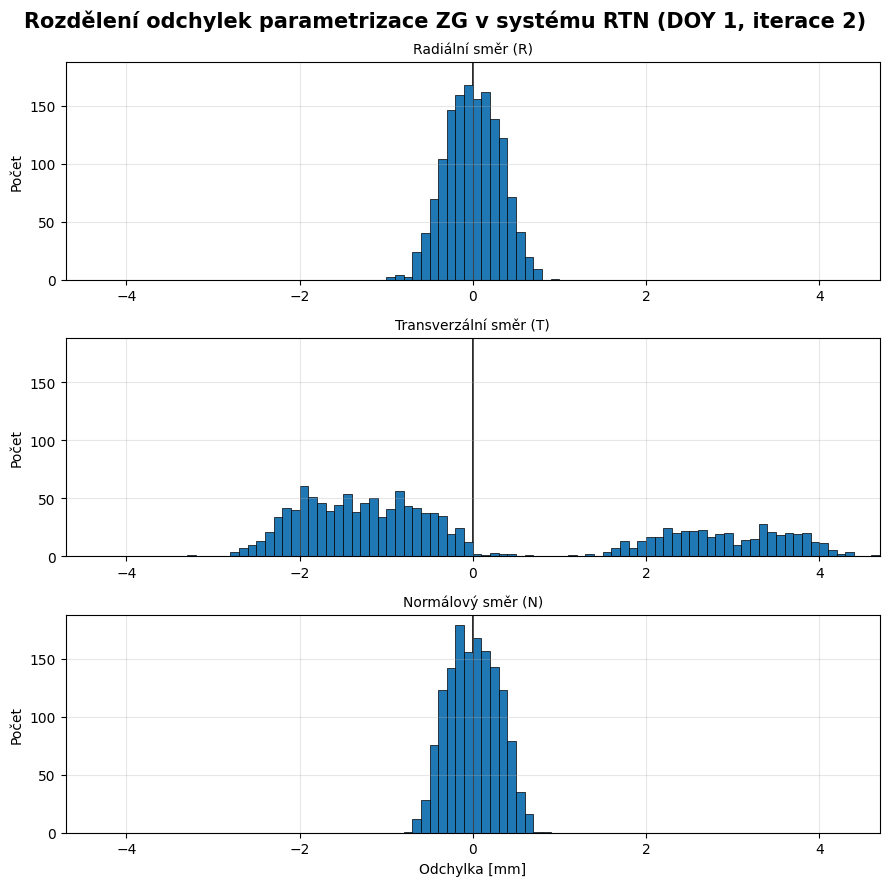

In [13]:
# ============================================================
# 14) RTN RESIDUAL HISTOGRAMS FOR ONE DAY
# ============================================================

# Use the same day as the time-series plot.

if residuals_df.empty:
    print("residuals_df is empty -> nothing to plot.")
else:
    selected_doy = residuals_df["doy"].min() if SELECT_DOY is None else SELECT_DOY
    day_df = residuals_df[residuals_df["doy"] == selected_doy].copy()

    if day_df.empty:
        print("No data for SELECT_DOY:", selected_doy)
    else:
        fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

        components = [
            ("radial_mm", "Radiální směr (R)"),
            ("along_mm", "Transverzální směr (T)"),
            ("out_mm", "Normálový směr (N)"),
        ]

        vals_all = day_df[["radial_mm", "along_mm", "out_mm"]].to_numpy(dtype=float)
        max_abs = np.nanmax(np.abs(vals_all))
        xmax = np.ceil(max_abs * 10) / 10
        bin_step = 0.1 if xmax <= 10 else 0.5
        bins = np.arange(-xmax, xmax + bin_step, bin_step)

        for ax, (col, title) in zip(axes, components):
            vals = day_df[col].to_numpy(dtype=float)
            ax.hist(vals, bins=bins, edgecolor="black", linewidth=0.5)
            ax.axvline(0, color="black", linewidth=1.2, zorder=0)
            ax.set_ylabel("Počet")
            ax.set_title(title, fontsize=10)
            ax.set_xlim(-xmax, xmax)
            ax.tick_params(axis="x", labelbottom=True)
            ax.grid(True, alpha=0.3)

        axes[-1].set_xlabel("Odchylka [mm]")

        fig.suptitle(
            f"Rozdělení odchylek parametrizace {SOLUTION} v systému RTN (DOY {selected_doy}, iterace {ITERATION})",
            fontsize=15,
            fontweight="bold",
        )

        plt.tight_layout()
        if SAVE_PLOTS:
            fig.savefig(PLOTS_DIR / f"{SOLUTION.lower()}_rtn_histograms_doy{selected_doy:03d}_iter{ITERATION}.pdf", bbox_inches="tight")
        plt.show()


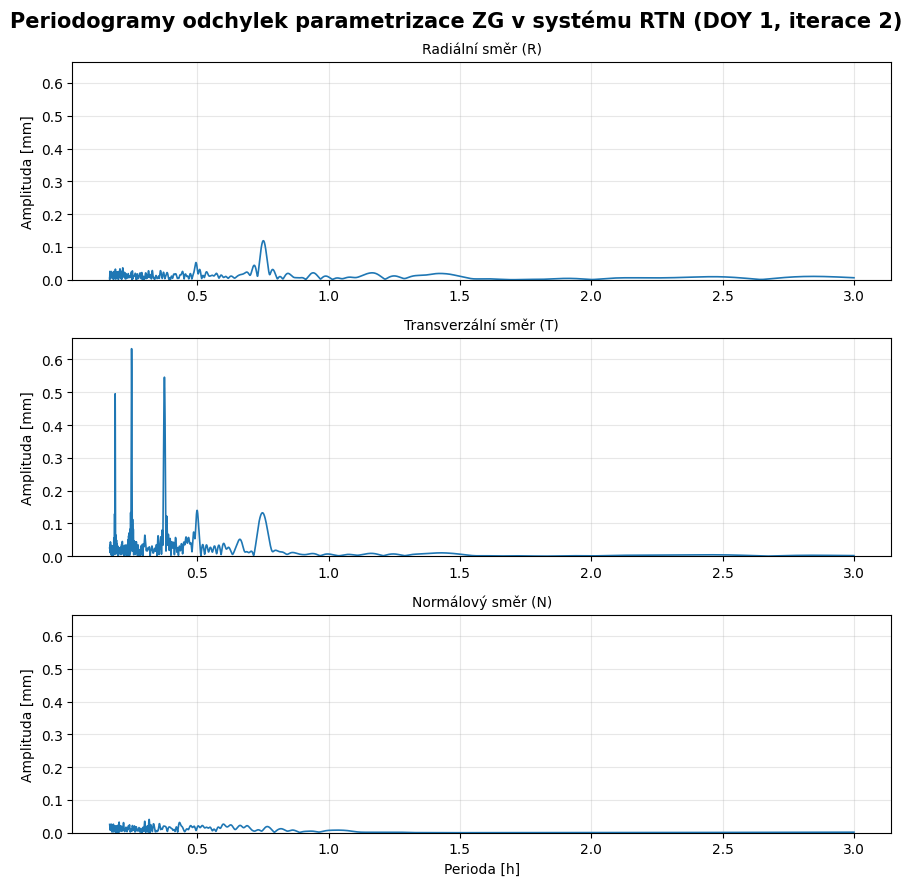

In [14]:
# ============================================================
# 15) RTN RESIDUAL PERIODOGRAMS FOR ONE DAY
# ============================================================

if residuals_df.empty:
    print("residuals_df je prázdný -> není co zobrazit.")
else:
    selected_doy = residuals_df["doy"].min() if SELECT_DOY is None else SELECT_DOY
    day_df = residuals_df[residuals_df["doy"] == selected_doy].copy()

    if day_df.empty:
        print("Žádná data pro SELECT_DOY:", selected_doy)
    else:
        day_df["t_sec"] = (day_df["epoch"] - day_df["epoch"].min()).dt.total_seconds()

        components = [
            ("radial_mm",  "Radiální směr (R)"),
            ("along_mm",   "Transverzální směr (T)"),
            ("out_mm",     "Normálový směr (N)"),
        ]

        periodograms = {}
        for col, _ in components:
            pg = compute_periodogram(
                day_df,
                method="lomb_scargle",
                time_col="t_sec",
                value_cols=col,
                min_period=600,    # 10 minut v sekundách
                max_period=10800,  # 3 hodiny v sekundách
            )
            pg["period_h"] = pg["period"] / 3600.0
            periodograms[col] = pg

        global_max = max(pg["amplitude"].max() for pg in periodograms.values())

        fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

        for ax, (col, title) in zip(axes, components):
            pg = periodograms[col]
            ax.plot(pg["period_h"], pg["amplitude"], linewidth=1.2, zorder=2)
            ax.set_title(title, fontsize=10)
            ax.set_ylabel("Amplituda [mm]")
            ax.set_ylim(0, global_max * 1.05)
            ax.tick_params(axis="x", labelbottom=True)
            ax.grid(True, alpha=0.3)

        axes[-1].set_xlabel("Perioda [h]")

        fig.suptitle(
            f"Periodogramy odchylek parametrizace {SOLUTION} v systému RTN (DOY {selected_doy}, iterace {ITERATION})",
            fontsize=15,
            fontweight="bold",
        )

        plt.tight_layout()
        if SAVE_PLOTS:
            fig.savefig(
                PLOTS_DIR / f"{SOLUTION.lower()}_rtn_periodograms_doy{selected_doy:03d}_iter{ITERATION}.pdf",
                bbox_inches="tight",
            )
        plt.show()